<a href="https://colab.research.google.com/github/yesahek/CatsVsDogs-Image-Classifier/blob/main/notebooks/preprocess.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sys
from pathlib import Path
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Find a sample Image

In [3]:
#  Find a sample image
# Look in processed/train/cat first, then fall back to raw/Cat
root_dir = Path("/content/drive/MyDrive/cats_vs_dogs_classifier/data/")

sample_path = None
search_dirs = [
    Path(f"{root_dir}/processed/train/cat"),
    Path(f"{root_dir}/processed/train/dog"),
    Path(f"{root_dir}/raw/Cat"),
    Path(f"{root_dir}/raw/Dog"),
]
for d in search_dirs:
    if d.exists():
        files = list(d.iterdir())
        if files:
            sample_path = files[0]
            break

In [4]:
print(sample_path)

/content/drive/MyDrive/cats_vs_dogs_classifier/data/processed/train/cat/cat_8630.jpg


In [5]:
if sample_path is None:
    print("No images found. Run script 02 first to split the dataset.")
    sys.exit(1)

In [6]:
print(f"Using sample image: {sample_path}")

Using sample image: /content/drive/MyDrive/cats_vs_dogs_classifier/data/processed/train/cat/cat_8630.jpg


In [7]:
# Load the raw image
import tensorflow as tf
from PIL import Image

raw_img = Image.open(sample_path).convert("RGB")
raw_arr = np.array(raw_img, dtype=np.float32)

print(f"""
RAW IMAGE (straight from disk):
  Size   : {raw_img.size[0]} x {raw_img.size[1]} pixels
  Shape  : {raw_arr.shape}   (height, width, RGB channels)
  Dtype  : {raw_arr.dtype}
  Min px : {raw_arr.min():.0f}
  Max px : {raw_arr.max():.0f}
  Mean px: {raw_arr.mean():.1f}
""")


RAW IMAGE (straight from disk):
  Size   : 500 x 432 pixels
  Shape  : (432, 500, 3)   (height, width, RGB channels)
  Dtype  : float32
  Min px : 0
  Max px : 255
  Mean px: 143.0



In [8]:
# Resize ────────────────────────────────────────────────────────────
IMG_SIZE = (224, 224)

img_tensor  = tf.constant(raw_arr)                     # convert to tensor
img_resized = tf.image.resize(img_tensor, IMG_SIZE)    # resize to 224x224

print(f"""AFTER RESIZE to {IMG_SIZE}:
  Shape  : {img_resized.shape}
  Min px : {img_resized.numpy().min():.0f}
  Max px : {img_resized.numpy().max():.0f}
  (pixel values unchanged — only the dimensions changed)
""")

AFTER RESIZE to (224, 224):
  Shape  : (224, 224, 3)
  Min px : 0
  Max px : 255
  (pixel values unchanged — only the dimensions changed)



In [9]:
# Normalise ─────────────────────────────────────────────────────────
img_normalised = tf.cast(img_resized, tf.float32) / 255.0

print(f"""AFTER NORMALISATION (÷ 255):
  Shape  : {img_normalised.shape}
  Dtype  : {img_normalised.dtype}
  Min px : {img_normalised.numpy().min():.4f}
  Max px : {img_normalised.numpy().max():.4f}
  Mean px: {img_normalised.numpy().mean():.4f}
  (same image, values now between 0.0 and 1.0)
""")

AFTER NORMALISATION (÷ 255):
  Shape  : (224, 224, 3)
  Dtype  : <dtype: 'float32'>
  Min px : 0.0000
  Max px : 1.0000
  Mean px: 0.5604
  (same image, values now between 0.0 and 1.0)



In [ ]:
# Show pixel-level example
print("Example pixel transformation (top-left corner, first 5 pixels):")
print(f"  Before: {img_resized.numpy()[0, :5, 0].astype(int).tolist()}")
print(f"  After : {[round(v, 3) for v in img_normalised.numpy()[0, :5, 0].tolist()]}")
print()
print("Preprocessing done!")

Example pixel transformation (top-left corner, first 5 pixels):
  Before: [207, 207, 207, 207, 208]
  After : [0.812, 0.812, 0.812, 0.813, 0.816]

Preprocessing done!


# Side-by-side Visualisation

# Side-by-side Visualisation
# Original → Resized → Normalised in one figure.

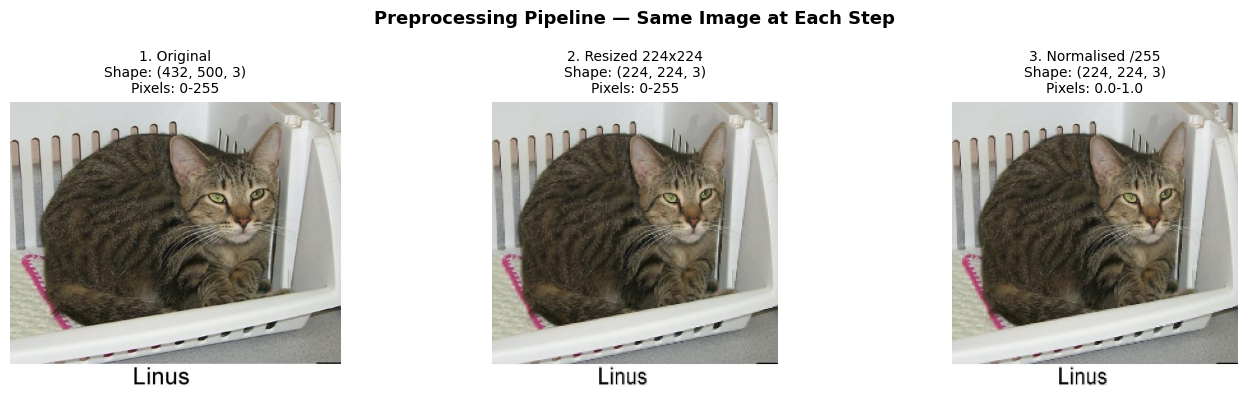

The image looks identical. Preprocessing only changes the numbers, not the visual content.


In [10]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(raw_img)
axes[0].set_title(f"1. Original\nShape: {raw_arr.shape}\nPixels: 0-255", fontsize=10)
axes[1].imshow(img_resized.numpy().astype("uint8"))
axes[1].set_title(f"2. Resized 224x224\nShape: {img_resized.shape}\nPixels: 0-255", fontsize=10)
axes[2].imshow(img_normalised.numpy())
axes[2].set_title(f"3. Normalised /255\nShape: {img_normalised.shape}\nPixels: 0.0-1.0", fontsize=10)
for ax in axes: ax.axis("off")
plt.suptitle("Preprocessing Pipeline — Same Image at Each Step", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()
print("The image looks identical. Preprocessing only changes the numbers, not the visual content.")

# Preprocess_image

In [11]:
def preprocess_image(image, label):
    """
    Applied to EVERY image in ALL splits (train, val, test).

    image : tf.Tensor  shape (H, W, 3)  dtype uint8
    label : tf.Tensor  scalar  0=cat  1=dog

    Returns:
      image : float32  shape (224, 224, 3)  range [0.0, 1.0]
      label : unchanged
    """
    image = tf.image.resize(image, IMG_SIZE)      # step 1: resize
    image = tf.cast(image, tf.float32) / 255.0    # step 2: normalise
    return image, label

img_t = tf.constant(raw_arr, dtype=tf.float32)
processed, _ = preprocess_image(img_t, tf.constant(0))
print(f"Input  shape : {img_t.shape}   dtype: {img_t.dtype}")
print(f"Output shape : {processed.shape}  dtype: {processed.dtype}")
print(f"Output range : {processed.numpy().min():.4f} - {processed.numpy().max():.4f}")
print("preprocess_image() works correctly ✅")

Input  shape : (432, 500, 3)   dtype: <dtype: 'float32'>
Output shape : (224, 224, 3)  dtype: <dtype: 'float32'>
Output range : 0.0000 - 1.0000
preprocess_image() works correctly ✅


# Data Augmentation

In [12]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),        # mirror: cat facing left = cat facing right
    layers.RandomRotation(0.20),            # rotate up to +/- 20 degrees
    layers.RandomZoom(0.15),                # zoom in/out up to +/- 15%
    layers.RandomTranslation(0.10, 0.10),   # shift up to +/- 10%
], name="data_augmentation")

print("Augmentation pipeline:")
for layer in data_augmentation.layers:
    print(f"  {layer.name}")

Augmentation pipeline:
  random_flip
  random_rotation
  random_zoom
  random_translation


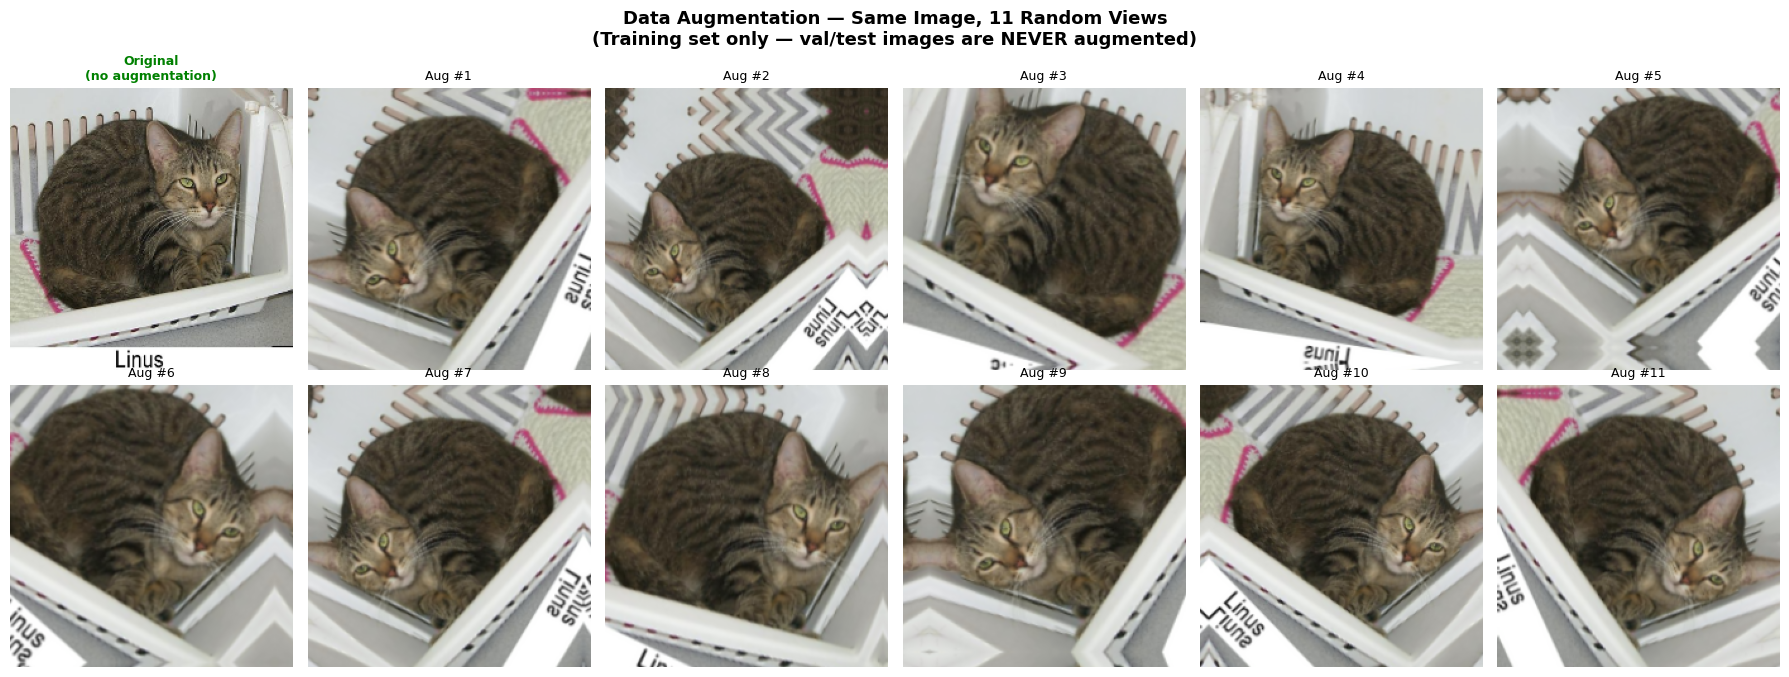

Each version generated on-the-fly — nothing extra saved to disk.


In [13]:
# Visualise: same image, 11 different augmented versions
sample_arr   = img_normalised.numpy()
sample_batch = tf.expand_dims(sample_arr, axis=0)   # (1, 224, 224, 3)

fig, axes = plt.subplots(2, 6, figsize=(18, 7))
fig.suptitle(
    "Data Augmentation — Same Image, 11 Random Views\n"
    "(Training set only — val/test images are NEVER augmented)",
    fontsize=13, fontweight="bold")

axes[0, 0].imshow(sample_arr)
axes[0, 0].set_title("Original\n(no augmentation)", fontsize=9, fontweight="bold", color="green")
axes[0, 0].axis("off")

for i, ax in enumerate(list(axes.flat)[1:]):
    aug = data_augmentation(sample_batch, training=True)[0].numpy()
    ax.imshow(np.clip(aug, 0, 1))
    ax.set_title(f"Aug #{i+1}", fontsize=9)
    ax.axis("off")

plt.tight_layout(); plt.show()
print("Each version generated on-the-fly — nothing extra saved to disk.")

# tf.data pipline

In [14]:
from pathlib import Path
import os

BATCH_SIZE  = 32
AUTOTUNE    = tf.data.AUTOTUNE
CLASS_NAMES = ["cat", "dog"]   # index 0=cat, index 1=dog — ORDER MATTERS

PROCESSED_DIR = Path("/content/drive/MyDrive/cats_vs_dogs_classifier/data/processed")

def build_dataset(directory, training=False, batch_size=BATCH_SIZE, seed=42):
    ds = tf.keras.utils.image_dataset_from_directory(
        directory,
        labels      = "inferred",     # cat/ subfolder -> 0,  dog/ -> 1
        label_mode  = "binary",       # 0.0 or 1.0  (matches sigmoid output)
        class_names = CLASS_NAMES,    # explicit order: cat=0, dog=1
        image_size  = IMG_SIZE,
        batch_size  = batch_size,
        shuffle     = training,
        seed        = seed,
    )
    ds = ds.map(preprocess_image, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(
            lambda x, y: (data_augmentation(x, training=True), y),
            num_parallel_calls=AUTOTUNE,
        )
    return ds.cache().prefetch(AUTOTUNE)

train_ds = build_dataset(str(PROCESSED_DIR / "train"), training=True)
val_ds   = build_dataset(str(PROCESSED_DIR / "val"),   training=False)
test_ds  = build_dataset(str(PROCESSED_DIR / "test"),  training=False)

print("All three datasets built ✅")
print("  train_ds -> shuffle=True,  augmentation=ON")
print("  val_ds   -> shuffle=False, augmentation=OFF")
print("  test_ds  -> shuffle=False, augmentation=OFF")

Found 16000 files belonging to 2 classes.
Found 4000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.
All three datasets built ✅
  train_ds -> shuffle=True,  augmentation=ON
  val_ds   -> shuffle=False, augmentation=OFF
  test_ds  -> shuffle=False, augmentation=OFF


  images.shape : (32, 224, 224, 3)
  labels.shape : (32, 1)
  dtype        : <dtype: 'float32'>
  pixel range  : 0.0000 - 1.0000
  labels first 8: [0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0]  (0=cat, 1=dog)


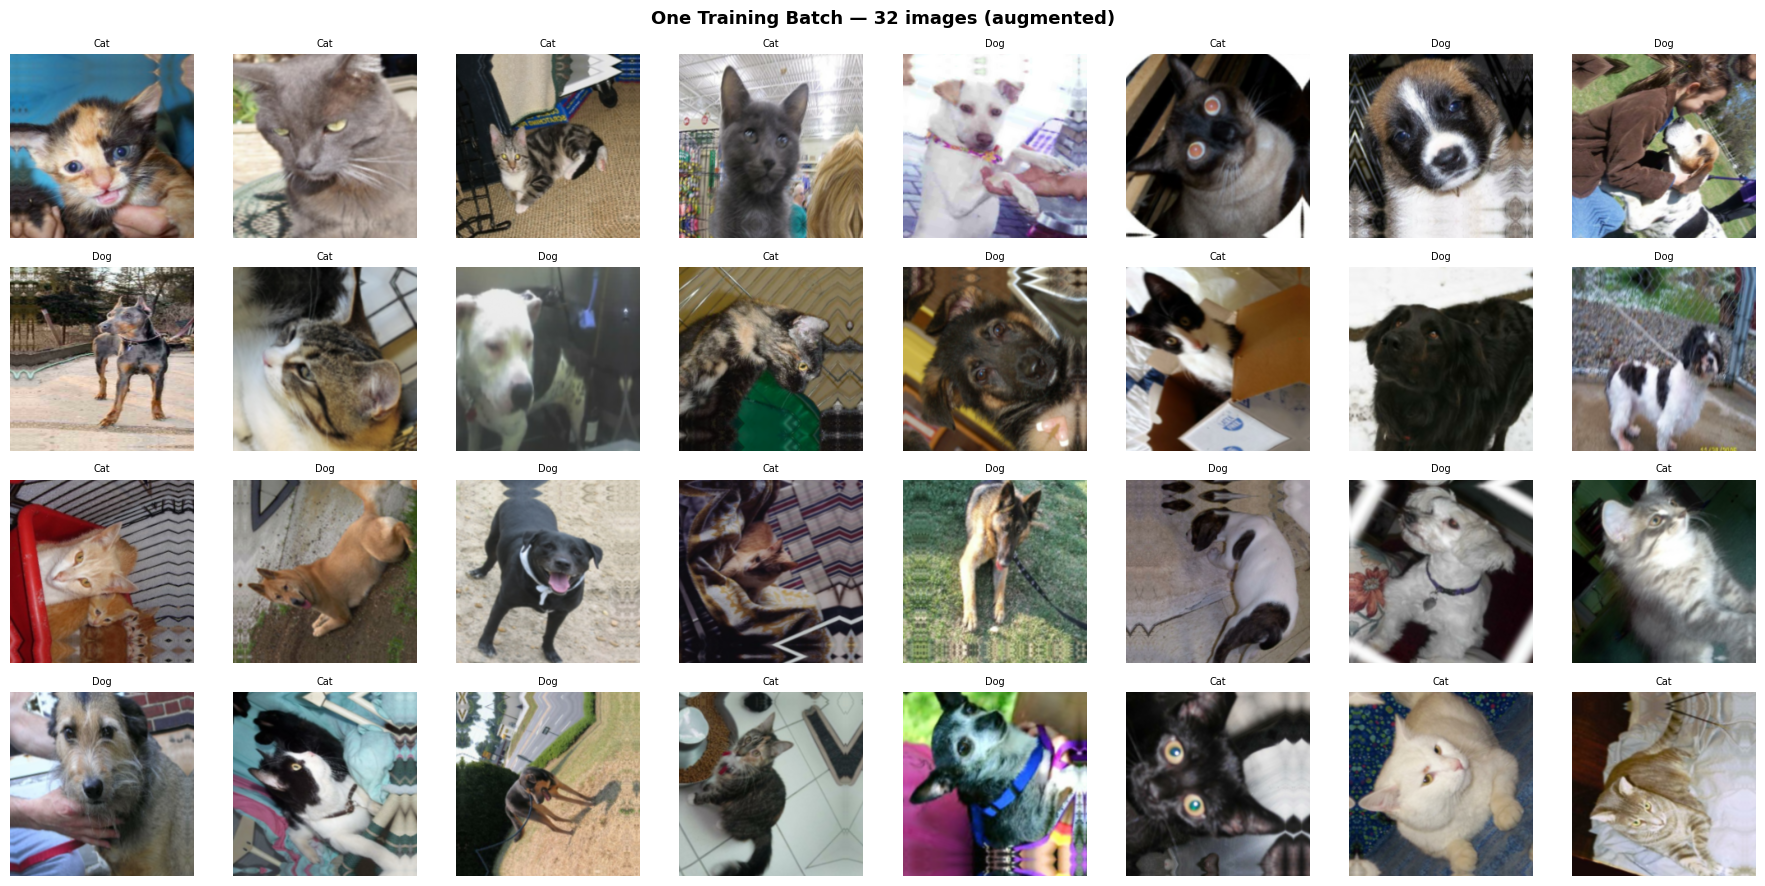

In [15]:
# Inspect one batch
for images, labels in train_ds.take(1):
    print(f"  images.shape : {images.shape}")
    print(f"  labels.shape : {labels.shape}")
    print(f"  dtype        : {images.dtype}")
    print(f"  pixel range  : {images.numpy().min():.4f} - {images.numpy().max():.4f}")
    print(f"  labels first 8: {labels.numpy().flatten()[:8].tolist()}  (0=cat, 1=dog)")

    fig, axes = plt.subplots(4, 8, figsize=(18, 9))
    fig.suptitle(f"One Training Batch — {images.shape[0]} images (augmented)", fontsize=13, fontweight="bold")
    for i, ax in enumerate(axes.flat):
        if i < len(images):
            ax.imshow(np.clip(images[i].numpy(), 0, 1))
            ax.set_title("Cat" if labels[i]==0 else "Dog", fontsize=7)
        ax.axis("off")
    plt.tight_layout(); plt.show()
    break

# Prepare_dataset() - One call for all 3 split

In [16]:
def prepare_dataset(processed_dir, batch_size=BATCH_SIZE, seed=42):
    return (
        build_dataset(os.path.join(processed_dir, "train"), True,  batch_size, seed),
        build_dataset(os.path.join(processed_dir, "val"),   False, batch_size, seed),
        build_dataset(os.path.join(processed_dir, "test"),  False, batch_size, seed),
    )

train_ds, val_ds, test_ds = prepare_dataset(str(PROCESSED_DIR))
print("✅ All 3 datasets ready:")
print("   train_ds, val_ds, test_ds = prepare_dataset(PROCESSED_DIR)")

Found 16000 files belonging to 2 classes.
Found 4000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.
✅ All 3 datasets ready:
   train_ds, val_ds, test_ds = prepare_dataset(PROCESSED_DIR)


#Load single image() used by...

In [17]:
def load_single_image(image_path):
    """
    Load one image for inference (used by Flask app).

    Steps:
      1. Load + resize to 224x224
      2. Normalise pixels to [0, 1]
      3. Add batch dim: (224,224,3) -> (1,224,224,3)

    Why the batch dimension?
      Model always expects (batch_size, H, W, C).
      For one image we pass a 'batch of 1'.
    """
    img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
    arr = tf.keras.utils.img_to_array(img) / 255.0
    return tf.expand_dims(arr, axis=0)

single = load_single_image(str(sample_path))
print(f"Input file   : {sample_path.name}")
print(f"Output shape : {single.shape}")
print(f"               The '1' is the batch dimension")
print(f"Pixel range  : {single.numpy().min():.4f} - {single.numpy().max():.4f}")
print()
print("How Flask uses this:")
print("  tensor = load_single_image(uploaded_path)")
print("  prob   = float(model.predict(tensor)[0][0])  # probability of Dog")
print("  label  = 'Dog' if prob >= 0.5 else 'Cat'")

Input file   : cat_8630.jpg
Output shape : (1, 224, 224, 3)
               The '1' is the batch dimension
Pixel range  : 0.0000 - 1.0000

How Flask uses this:
  tensor = load_single_image(uploaded_path)
  prob   = float(model.predict(tensor)[0][0])  # probability of Dog
  label  = 'Dog' if prob >= 0.5 else 'Cat'
